In [1]:
import pandas as pd
import numpy as np
import os
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
base_path = os.path.join(os.path.dirname(os.path.abspath('')), "data\\car_prices.csv")
df = pd.read_csv(base_path)

##### Comparision of depreciation rates for the 10 most popular brand (e.g. BMW vs Toyota)

<Figure size 800x600 with 0 Axes>

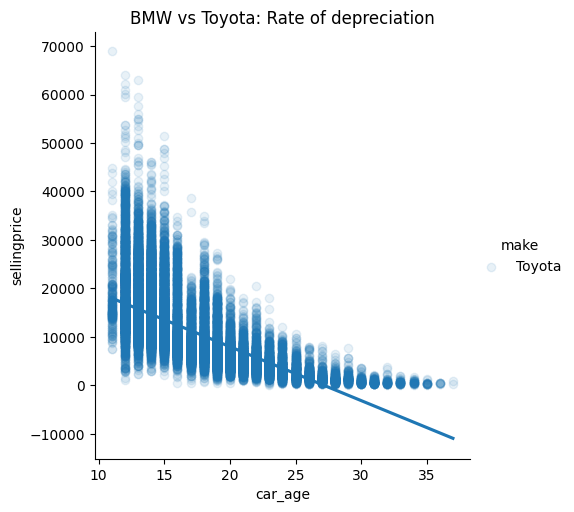

In [3]:
# Regression plot with scatter

subset = df[df['make'].isin(['BMW', 'Toyota'])].copy()
subset['car_age'] = 2026 - subset['year']

plt.figure(figsize=(8,6))
sns.lmplot(data=subset, x='car_age', y='sellingprice', hue='make', scatter_kws={'alpha':0.1})
plt.title("BMW vs Toyota: Rate of depreciation")
plt.show()

In [6]:
# VIF calculating

features = df[~df[['year', 'odometer', 'condition']].isna().any(axis=1)][['year', 'odometer', 'condition']]
# add constant becauser VIF wants to
features_with_const = sm.add_constant(features)

vif_data = pd.DataFrame()
vif_data["feature"] = features_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(features_with_const.values, i) 
                   for i in range(len(features_with_const.columns))]

print(vif_data)

     feature            VIF
0      const  674483.336114
1       year       2.540228
2   odometer       2.499110
3  condition       1.140766


*Multicollinearity check (VIF) confirmed that features are acceptable and all of them will be included in the future model.*

In [8]:
# LINEAR REGRESSION
clean_data = df.dropna(subset=['sellingprice', 'year', 'condition', 'odometer'])
clean_data['car_age'] = 2026 - clean_data['year']

X = clean_data['car_age']
y = clean_data['sellingprice']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

C:\Users\CTK109\AppData\Local\Temp\ipykernel_10268\2720598333.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_data['car_age'] = 2026 - clean_data['year']


                            OLS Regression Results                            
Dep. Variable:           sellingprice   R-squared:                       0.336
Model:                            OLS   Adj. R-squared:                  0.336
Method:                 Least Squares   F-statistic:                 2.771e+05
Date:                Thu, 30 Apr 2026   Prob (F-statistic):               0.00
Time:                        09:52:18   Log-Likelihood:            -5.6879e+06
No. Observations:              546976   AIC:                         1.138e+07
Df Residuals:                  546974   BIC:                         1.138e+07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.672e+04     44.915    817.585      0.0

In [ ]:
# MULTIPLE REGRESSION
clean_data['age_condition'] = clean_data['car_age'] * clean_data['condition']
X_multi = clean_data[['car_age', 'age_condition']]
X_multi = sm.add_constant(X_multi)
y = clean_data['sellingprice']

model_multi = sm.OLS(y, X_multi).fit()
print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:           sellingprice   R-squared:                       0.349
Model:                            OLS   Adj. R-squared:                  0.349
Method:                 Least Squares   F-statistic:                 1.468e+05
Date:                Tue, 28 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:22:49   Log-Likelihood:            -5.6824e+06
No. Observations:              546976   AIC:                         1.136e+07
Df Residuals:                  546973   BIC:                         1.136e+07
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          3.456e+04     49.015    705.046

C:\Users\CTK109\AppData\Local\Temp\ipykernel_13896\3973006070.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_data['age_condition'] = clean_data['car_age'] * clean_data['condition']


In [ ]:
# LINEAR REGRESSION IN LOOP
results = {}
top_10_makes = df['make'].value_counts().nlargest(10).index

for make in top_10_makes:
    brand_data = df[df['make'] == make].dropna(subset=['sellingprice', 'year'])
    brand_data['car_age'] = 2026 - brand_data['year']

    X = sm.add_constant(brand_data['car_age'])
    y = brand_data['sellingprice']
    model = sm.OLS(y, X).fit()

    results[make] = {
        'R2': model.rsquared,
        'Depreciation': model.params['car_age'],
        'Count': len(brand_data)
    }

res_df = pd.DataFrame(results).T
print(res_df.sort_values(by='Depreciation'))

                 R2  Depreciation    Count
Bmw        0.635225  -3060.061969  20955.0
Chrysler   0.658466  -1509.536784  17740.0
Kia        0.598457  -1503.998481  18095.0
Ford       0.389108  -1439.904854  94431.0
Hyundai    0.483131  -1286.846473  21856.0
Chevrolet  0.308642  -1268.735249  60988.0
Dodge      0.429596  -1228.470554  31196.0
Honda      0.641934  -1218.133679  27480.0
Toyota     0.453169  -1112.293786  40057.0
Nissan     0.410934  -1110.352427  54074.0


*Analyzing regression model shows cars age great impact to the price (e.g. BMW is far more delicate on the its year). In general it isn't good R2 score but it is a good beginnig.*

MAE: 3380.04$
RMSE: 4175.93$


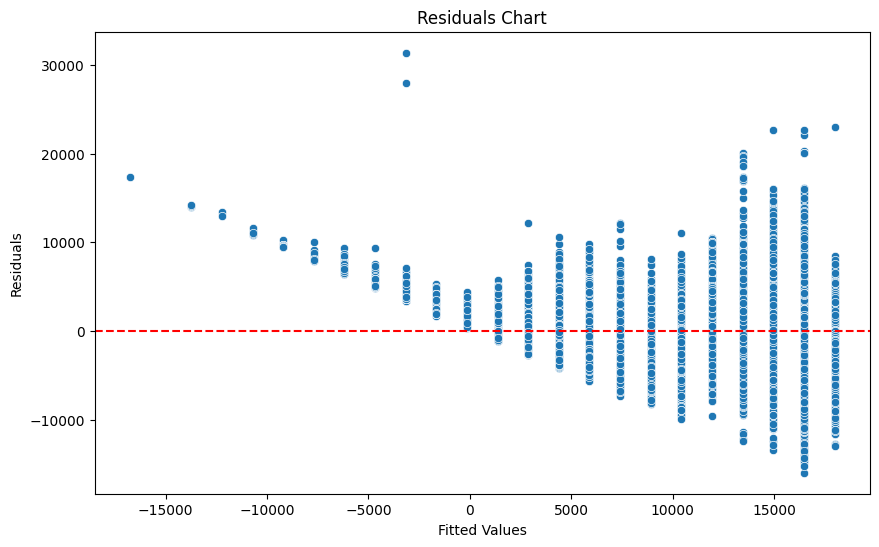

In [12]:
# Residuals analyze
"""Sensitivity to errors: RMSE places greater weight on large errors 
(due to squaring), while MAE treats all errors proportionally.
Resistance to outliers: MAE is more stable and resistant to individual, extreme errors than RMSE.
Interpretation: Both metrics are expressed in the same units as the target variable.
Application: Use MAE when you care about the average error and resistance to outliers. 
Choose RMSE when large errors are particularly undesirable."""

y_pred = model.predict(X)
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"MAE: {mae:.2f}$")
print(f"RMSE: {rmse:.2f}$")

residuals = model.resid
fitted_values = model.fittedvalues

plt.figure(figsize=(10,6))
sns.scatterplot(x=fitted_values, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals Chart")
plt.show()

*This chart shows that the model is not handling well the higher prices. It want to adjust cheaper cars prices, but in the other hand the luxury cars are undervalued.*